In [35]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.manifold import TSNE
from sklearn.preprocessing import MinMaxScaler
from matplotlib.offsetbox import AnnotationBbox, OffsetImage

In [36]:
# PREPARACIÓN DE DATOS
print("Cargando datos...")
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

Cargando datos...


In [37]:
# DEFINICIÓN DEL MODELO
print("Construyendo modelo...")

# Definimos explícitamente el tensor de entrada
inputs = tf.keras.Input(shape=(28, 28))

# Conectamos las capas una tras otra
x = tf.keras.layers.Flatten()(inputs)
x = tf.keras.layers.Dense(256, activation='relu')(x)

# Guardamos una referencia a esta capa específica (los embeddings)
embeddings = tf.keras.layers.Dense(128, activation='relu')(x)

# Capa de salida final
outputs = tf.keras.layers.Dense(10, activation='softmax')(embeddings)

# Creamos el modelo principal para entrenar
model = tf.keras.Model(inputs=inputs, outputs=outputs)

# Creamos el extractor usando las mismas variables
feature_extractor = tf.keras.Model(inputs=inputs, outputs=embeddings)

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

Construyendo modelo...


In [38]:
# ENTRENAMIENTO
print("Entrenando (3 épocas)...")
model.fit(x_train, y_train, epochs=3, batch_size=128, verbose=1)

Entrenando (3 épocas)...
Epoch 1/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8547 - loss: 0.5025
Epoch 2/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9658 - loss: 0.1152
Epoch 3/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9787 - loss: 0.0716


Generando visualización t-SNE...


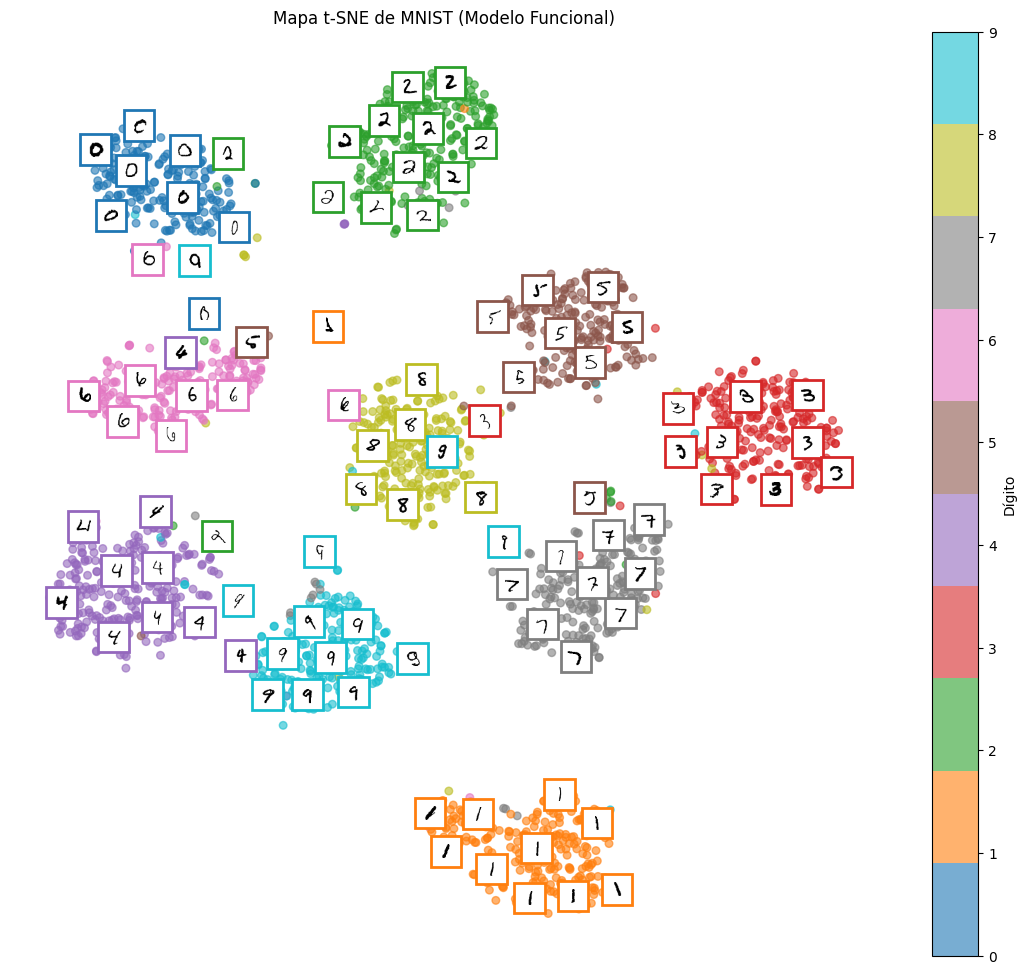

In [39]:
# t-SNE Y VISUALIZACIÓN
print("Generando visualización t-SNE...")

# Muestra reducida para velocidad
n_samples = 2500
x_subset = x_test[:n_samples]
y_subset = y_test[:n_samples]

# Obtenemos las características usando el extractor que creamos arriba
features = feature_extractor.predict(x_subset, verbose=0)

# Reducción de dimensionalidad
tsne = TSNE(n_components=2, init="pca", learning_rate="auto", random_state=42)
X_2D = tsne.fit_transform(features)

# Escalado
scaler = MinMaxScaler()
X_2D_scaled = scaler.fit_transform(X_2D)

# Gráfico
plt.figure(figsize=(14, 12))
cmap = plt.cm.tab10

# Puntos
plt.scatter(X_2D_scaled[:, 0], X_2D_scaled[:, 1], c=y_subset, s=30, cmap=cmap, alpha=0.6)
plt.colorbar(ticks=range(10), label="Dígito")

# Imágenes
ax = plt.gca()
image_positions = np.array([[500., 500.]])

for index, position in enumerate(X_2D_scaled):
    dist = np.sum((position - image_positions) ** 2, axis=1)
    if np.min(dist) > 0.0025:
        image_positions = np.r_[image_positions, [position]]
        imagebox = AnnotationBbox(
            OffsetImage(x_subset[index], cmap="binary", zoom=0.5),
            position,
            bboxprops={"edgecolor": cmap(y_subset[index]), "lw": 2}
        )
        ax.add_artist(imagebox)

plt.title("Mapa t-SNE de MNIST (Modelo Funcional)")
plt.axis("off")
plt.show()